# Sentiment_Analysis -- data & labeling analysis (run 1)

Analyzes the 10,000-doc pool sampled by `scripts/build_dataset.py` and the labels produced by
5 parallel Claude Code Sonnet 5 subagents (see `../plan.md` for the full design). Covers:
corpus/sample composition, per-agent label distributions (the label-collapse check), inter-annotator
agreement on the 1,000-doc overlap set, a check on an emergent tie-breaking rule agents self-reported,
the final merged label distribution with examples, label vs. script/source, and the disagreement set.

In [1]:
from __future__ import annotations

import json
import random
import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import arabic_reshaper

DATA_DIR = Path.cwd().resolve()
if DATA_DIR.name == "notebooks":
    DATA_DIR = DATA_DIR.parent / "data"
else:
    DATA_DIR = DATA_DIR / "Sentiment_Analysis" / "data"

# Same Arabic-safe rendering convention as every other eval notebook in this repo
# (Embeddings/glove/glove_eval.ipynb etc.) -- Tahoma/Arial before Segoe UI, reshape
# only (no bidi.get_display(), this stack already lays reshaped RTL glyphs out correctly).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]
ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")


def render_label(text: str) -> str:
    return arabic_reshaper.reshape(text) if ARABIC_RE.search(text) else text


def load_jsonl(path):
    return [json.loads(l) for l in Path(path).open("r", encoding="utf-8") if l.strip()]


pool = load_jsonl(DATA_DIR / "unlabeled_10k.jsonl")
pool_by_id = {r["id"]: r for r in pool}

batches = {i: load_jsonl(DATA_DIR / f"agent{i}_batch.jsonl") for i in range(1, 6)}
labels = {i: {r["id"]: r["label"] for r in load_jsonl(DATA_DIR / f"agent{i}_labels.jsonl")} for i in range(1, 6)}

LABELS = ["POS", "NEG", "NEU", "MIX", "UNSURE"]
LABEL_COLORS = {"POS": "#04663a", "NEG": "#c8102e", "NEU": "#74827b", "MIX": "#b8922f", "UNSURE": "#4a6fa5"}

final = load_jsonl(DATA_DIR / "labeled_10k.jsonl")
disagreements = load_jsonl(DATA_DIR / "disagreements.jsonl")

overlap_ids = sorted({r["id"] for r in batches[1] if r["shard"] == "overlap"})
assert all(set(r["id"] for r in batches[i] if r["shard"] == "overlap") == set(overlap_ids) for i in range(1, 6))

print(f"Pool: {len(pool):,} docs | Final labeled: {len(final):,} | Overlap set: {len(overlap_ids):,} | Disagreements: {len(disagreements)}")

Pool: 10,000 docs | Final labeled: 9,971 | Overlap set: 1,000 | Disagreements: 29


## 1. Corpus / sample overview

Confirms `build_dataset.py`'s stratified sampling landed where intended: 15% djelfa, 85%
social split evenly across the three script buckets.

By sample_group:
  social_arabic   2,834  (28.3%)
  social_latin    2,833  (28.3%)
  social_mixed    2,833  (28.3%)
  djelfa          1,500  (15.0%)


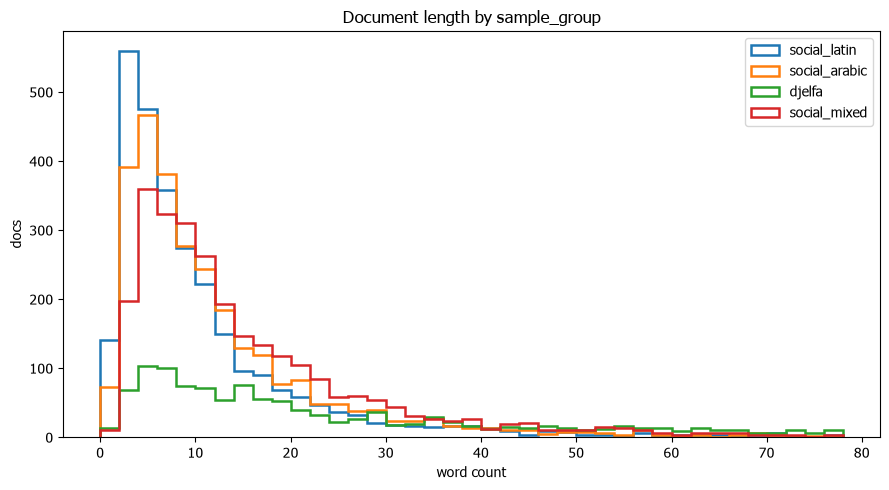

social_latin    mean= 11.6  median=   7  max= 556
social_arabic   mean= 12.9  median=   8  max= 448
djelfa          mean=104.2  median=  24  max=6179
social_mixed    mean= 19.4  median=  11  max= 692


In [2]:
group_counts = Counter(r["sample_group"] for r in pool)
print("By sample_group:")
for g, n in group_counts.most_common():
    print(f"  {g:15} {n:5,}  ({n / len(pool):.1%})")

def word_count(text): return len(text.split())

lengths_by_group = defaultdict(list)
for r in pool:
    lengths_by_group[r["sample_group"]].append(word_count(r["text"]))

fig, ax = plt.subplots(figsize=(9, 5))
for g in group_counts:
    ax.hist(lengths_by_group[g], bins=range(0, 80, 2), histtype="step", label=g, linewidth=1.8)
ax.set_xlabel("word count"); ax.set_ylabel("docs"); ax.set_title("Document length by sample_group")
ax.legend(); plt.tight_layout(); plt.show()

for g in group_counts:
    ls = lengths_by_group[g]
    print(f"{g:15} mean={np.mean(ls):5.1f}  median={np.median(ls):4.0f}  max={max(ls):4d}")

In [3]:
# A few random raw examples per group, sanity-checking the sample looks like what it should
rng = random.Random(0)
by_group = defaultdict(list)
for r in pool:
    by_group[r["sample_group"]].append(r)

for g, rows in by_group.items():
    print(f"=== {g} ===")
    for r in rng.sample(rows, 3):
        print(" -", r["text"].replace(chr(10), " / ")[:100])
    print()

=== social_latin ===
 - Les frontières sont pas sécuriser grands danger ❗❗ 👉👉
 - niveau zero vraiment cette chaine cest de lamerda jai perdu 3 minutes
 - Bzaf hyla❤

=== social_arabic ===
 - علاش هاد الأمور راهوم يصراو غير في المساجد نتاعنا ، في البلدان الإسلامية المجاورة ما سمعناش اخبار من
 - هذي كيكة مجنونة زدتيلها حبة بيض برك يعطيك الصحة
 - أين هي أمواله و فيما تبذر .

=== djelfa ===
 - لا تستغرب شيئا أخي الكريم ، فالمنظمة أقصد اتحاد العلماء المسلمين ، هي نفسها مدرجة في قوائم الإرهاب ،
 - الله ارحمه وتقبله واسكنه فسيح جنانك
 - التمحور / حول / الذات وتضخمها ورؤية الحياة / من / خلالها ... / من / أهم أسباب الفشل والبعد / عن / ال

=== social_mixed ===
 - +Oussama Hadid بصحتكم
 - مبروك حبيبتي تستاهلي كل خير مزيد من التألق إنشاء الله  / Gros bisous lahbiba
 - زوجي نور عيوني *سلام اختي الله افرحك في هذ لعواشر* /  /  *زوري قناة المراة الجزائرية oum nazim* 🔔🍋



## 2. Per-agent label distributions -- the label-collapse check

The prompt was written specifically against the documented risk that closed-set LLM labeling of
social-media text collapses onto one dominant class (see `../plan.md`'s research notes). This checks
it directly from the raw output files rather than trusting each agent's self-report.

,agent1,agent2,agent3,agent4,agent5
POS,1269,1330,1213,1271,1212
NEG,761,684,683,652,697
NEU,552,618,741,760,663
MIX,67,61,44,42,56
UNSURE,151,107,119,75,172


,agent1,agent2,agent3,agent4,agent5
POS,0.453,0.475,0.433,0.454,0.433
NEG,0.272,0.244,0.244,0.233,0.249
NEU,0.197,0.221,0.265,0.271,0.237
MIX,0.024,0.022,0.016,0.015,0.020
UNSURE,0.054,0.038,0.042,0.027,0.061


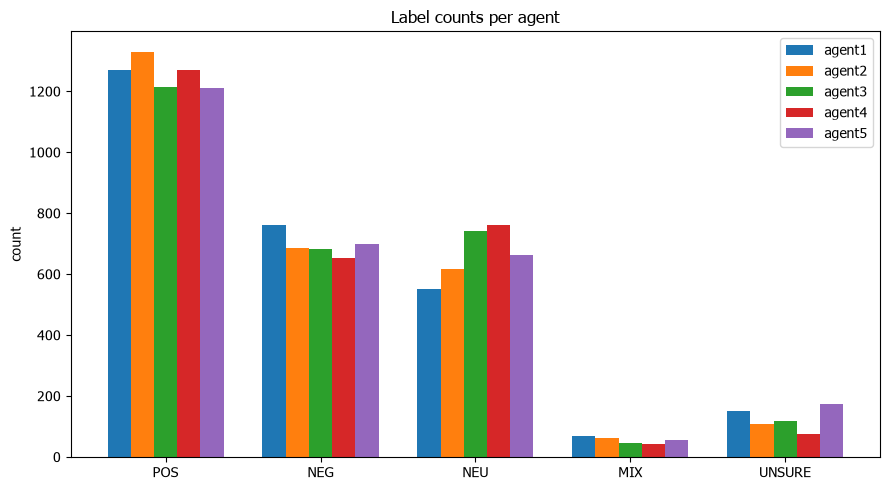

Max deviation from the 5-agent mean share, per label:
POS       0.025
NEG       0.023
NEU       0.041
MIX       0.005
UNSURE    0.018
dtype: float64


In [4]:
dist = pd.DataFrame({i: Counter(labels[i].values()) for i in range(1, 6)}).reindex(LABELS).fillna(0).astype(int)
dist.columns = [f"agent{i}" for i in range(1, 6)]
display(dist)
display((dist / dist.sum()).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(LABELS)); width = 0.15
for i in range(1, 6):
    ax.bar(x + (i - 3) * width, [dist[f"agent{i}"][l] for l in LABELS], width, label=f"agent{i}", color=None)
ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylabel("count"); ax.set_title("Label counts per agent")
ax.legend(); plt.tight_layout(); plt.show()

# Flag any agent whose distribution is a real outlier vs. the other four (not just noisier)
shares = (dist / dist.sum())
mean_share = shares.mean(axis=1)
print("Max deviation from the 5-agent mean share, per label:")
print((shares.sub(mean_share, axis=0)).abs().max(axis=1).round(3))

## 3. Inter-annotator agreement (1,000-item overlap set)

Proper Fleiss' kappa (not just the top-label vote share `merge_and_score.py` uses for its quick QA
number), a pairwise agent-vs-agent agreement matrix, and agreement broken down by script group --
testing whether Arabizi/mixed-script text is genuinely harder to agree on than Arabic script.

In [5]:
def fleiss_kappa(rows_by_item: list[Counter], categories: list[str]) -> float:
    # rows_by_item: one Counter per item, mapping category -> number of raters who picked it.
    # All items must have the same number of raters (N).
    n_items = len(rows_by_item)
    N = sum(rows_by_item[0].values())
    n_ij = np.array([[c.get(cat, 0) for cat in categories] for c in rows_by_item])
    P_i = ((n_ij ** 2).sum(axis=1) - N) / (N * (N - 1))
    P_bar = P_i.mean()
    p_j = n_ij.sum(axis=0) / (n_items * N)
    P_e_bar = (p_j ** 2).sum()
    return (P_bar - P_e_bar) / (1 - P_e_bar)

overlap_votes = [Counter(labels[i][doc_id] for i in range(1, 6)) for doc_id in overlap_ids]
kappa = fleiss_kappa(overlap_votes, LABELS)
print(f"Fleiss' kappa (5 raters x {len(overlap_ids):,} items, {len(LABELS)} categories): {kappa:.3f}")
print("(Krippendorff's/Fleiss' conventional reliability threshold: >= 0.667)")

top_vote_share = [max(c.values()) / 5 for c in overlap_votes]
print(f"\nSimple top-label vote share (merge_and_score.py's metric): mean={np.mean(top_vote_share):.1%}")

Fleiss' kappa (5 raters x 1,000 items, 5 categories): 0.684
(Krippendorff's/Fleiss' conventional reliability threshold: >= 0.667)

Simple top-label vote share (merge_and_score.py's metric): mean=87.5%


In [6]:
# Per-class agreement proxy: among overlap items whose 5-way majority label is L,
# how often do all 5 agents actually agree (mean top-vote share)?
majority_label = [c.most_common(1)[0][0] for c in overlap_votes]
per_class_share = defaultdict(list)
for lab, share in zip(majority_label, top_vote_share):
    per_class_share[lab].append(share)

print("Mean agreement (top-vote share) among items whose majority label is L:")
for lab in LABELS:
    vals = per_class_share.get(lab, [])
    if vals:
        print(f"  {lab:7} n={len(vals):4}  mean_share={np.mean(vals):.1%}")

Mean agreement (top-vote share) among items whose majority label is L:
  POS     n= 467  mean_share=90.0%
  NEG     n= 251  mean_share=89.5%
  NEU     n= 219  mean_share=84.1%
  MIX     n=  19  mean_share=74.7%
  UNSURE  n=  44  mean_share=73.2%


,agent1,agent2,agent3,agent4,agent5
agent1,1.000,0.855,0.827,0.856,0.684
agent2,0.855,1.000,0.829,0.855,0.700
agent3,0.827,0.829,1.000,0.857,0.712
agent4,0.856,0.855,0.857,1.000,0.690
agent5,0.684,0.700,0.712,0.690,1.000


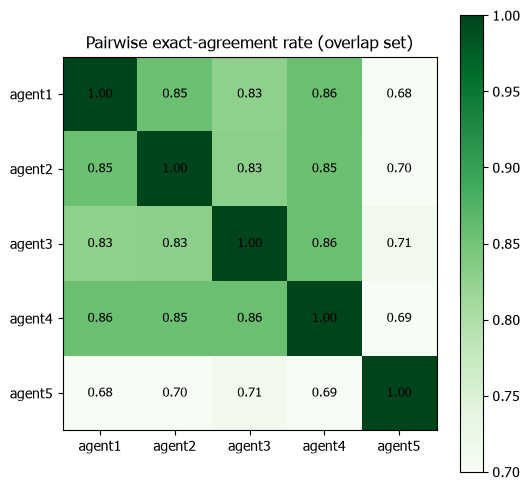

In [7]:
# Pairwise agent-vs-agent exact-agreement matrix on the overlap set
pair_matrix = pd.DataFrame(index=[f"agent{i}" for i in range(1, 6)], columns=[f"agent{i}" for i in range(1, 6)], dtype=float)
for i, j in combinations(range(1, 6), 2):
    agree = np.mean([labels[i][d] == labels[j][d] for d in overlap_ids])
    pair_matrix.loc[f"agent{i}", f"agent{j}"] = agree
    pair_matrix.loc[f"agent{j}", f"agent{i}"] = agree
for i in range(1, 6):
    pair_matrix.loc[f"agent{i}", f"agent{i}"] = 1.0
display(pair_matrix.round(3))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(pair_matrix.values, cmap="Greens", vmin=0.7, vmax=1.0)
ax.set_xticks(range(5)); ax.set_xticklabels(pair_matrix.columns)
ax.set_yticks(range(5)); ax.set_yticklabels(pair_matrix.index)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{pair_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Pairwise exact-agreement rate (overlap set)")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [8]:
# Agreement by script group -- is Arabizi/mixed genuinely harder than Arabic script?
overlap_group = {doc_id: pool_by_id[doc_id]["sample_group"] for doc_id in overlap_ids}
share_by_group = defaultdict(list)
for doc_id, share in zip(overlap_ids, top_vote_share):
    share_by_group[overlap_group[doc_id]].append(share)

print("Mean agreement (top-vote share) by sample_group, overlap items only:")
for g, vals in sorted(share_by_group.items(), key=lambda kv: -np.mean(kv[1])):
    print(f"  {g:15} n={len(vals):4}  mean_share={np.mean(vals):.1%}")

Mean agreement (top-vote share) by sample_group, overlap items only:
  social_latin    n= 276  mean_share=89.1%
  djelfa          n= 147  mean_share=89.0%
  social_mixed    n= 288  mean_share=86.6%
  social_arabic   n= 289  mean_share=86.3%


## 4. Checking the self-reported "blessing/condolence" tie-break rule

Agents 1 and 2 both reported (unprompted) applying their own convention: a health/affliction-tied
blessing ("may God heal you") or a condolence phrase gets NEG (grief/concern), while a plain
standalone blessing gets POS. This checks whether all 5 agents actually converged on it, using the
overlap set so every item has all 5 labels to compare.

In [9]:
# Keyword-based detection, not exhaustive -- just enough to pull a real sample to inspect
CONDOLENCE_RE = re.compile(r"\u0625\u0646\u0627 \u0644\u0644\u0647|\u0631\u062d\u0645\u0647 \u0627\u0644\u0644\u0647|\u0641\u0633\u064a\u062d \u062c\u0646\u0627\u062a\u0647")
HEALING_RE = re.compile(r"\u064a\u0634\u0641\u064a\u0643|\u0634\u0641\u0627\u0643 \u0627\u0644\u0644\u0647|\u0634\u0641\u0627\u0647 \u0627\u0644\u0644\u0647")

matches = [doc_id for doc_id in overlap_ids
           if CONDOLENCE_RE.search(pool_by_id[doc_id]["text"]) or HEALING_RE.search(pool_by_id[doc_id]["text"])]
print(f"{len(matches)} overlap items matched a condolence/healing-blessing keyword")

for doc_id in matches[:15]:
    votes = overlap_votes[overlap_ids.index(doc_id)]
    text = pool_by_id[doc_id]["text"].replace(chr(10), " / ")[:90]
    print(f"{dict(votes)!s:35} {text}")

15 overlap items matched a condolence/healing-blessing keyword
{'NEG': 4, 'POS': 1}                قال تعالى ... / {وبشر الصابرين الذين إذا أصابتهم مصيبة قالوا إنا لله وإنا إليه راجعون} / .
{'NEG': 5}                          إنا لله وإنا إليه راجعون / اللهم اغفر لها وارحمها / اللهم اجعل قبرها روضا من رياض الجنة ول
{'NEG': 4, 'NEU': 1}                انتقل إلى رحمة الله تعالى عمي الحنون الذي يقيم في خارج / إنا لله وإنا إليه راجعون. وإنا لف
{'NEU': 5}                          التحفة السنية بأقوال العلماء في إستعمال الجن في الرقية زعموا أنها شرعية / !! / قال الشيخ ص
{'NEG': 4, 'POS': 1}                إنا لله وإن لله راجعون رحم الله الفقيد وأسكنه فسيح جناته اللهم وسع له في قبره وأخلفه أهلا 
{'NEG': 4, 'NEU': 1}                سمية ** / إنا لله و إنا إليه راجعون / ربي يرحم جميع اموات المسلمين
{'NEU': 5}                          الاقتداء بالسلف بتحقيق مقاصدهم وليس في محاكاة وسائلهم الظرفية / الشدة نموذجا / بسم الله ال
{'NEU': 5}                          وقال الحافظ ابن كثير رحمه الله : / "

## 5. Final label distribution + examples

The merged `labeled_10k.jsonl`: unique-shard items use their one agent's label, overlap items use
the 5-agent majority vote (>=3/5).

Final labeled set: 9,971 items
  POS     4,471  (44.8%)
  NEG     2,472  (24.8%)
  NEU     2,418  (24.3%)
  MIX       178  (1.8%)
  UNSURE    432  (4.3%)


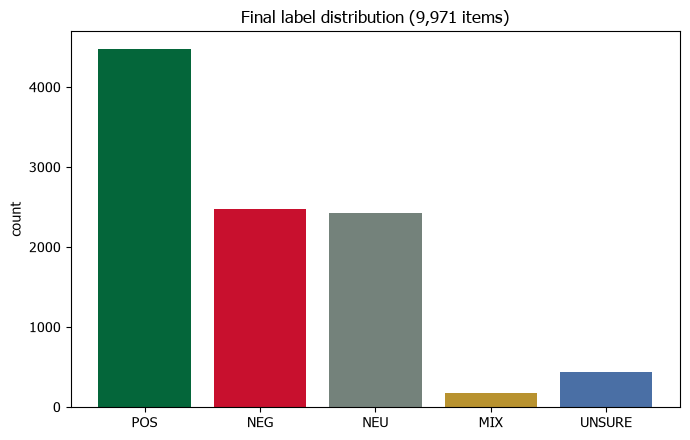

In [10]:
final_dist = Counter(r["label"] for r in final)
print(f"Final labeled set: {len(final):,} items")
for lab in LABELS:
    n = final_dist.get(lab, 0)
    print(f"  {lab:7} {n:5,}  ({n / len(final):.1%})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(LABELS, [final_dist.get(l, 0) for l in LABELS], color=[LABEL_COLORS[l] for l in LABELS])
ax.set_ylabel("count"); ax.set_title(f"Final label distribution ({len(final):,} items)")
plt.tight_layout(); plt.show()

In [11]:
final_by_label = defaultdict(list)
for r in final:
    final_by_label[r["label"]].append(r)

rng2 = random.Random(1)
for lab in LABELS:
    rows = final_by_label.get(lab, [])
    if not rows:
        continue
    print(f"=== {lab} (n={len(rows)}) ===")
    for r in rng2.sample(rows, min(4, len(rows))):
        print(" -", r["text"].replace(chr(10), " / ")[:100])
    print()

=== POS (n=4471) ===
 - مروان كي جاه جعفر قاسم عرف كيفاش يخرج الكوميديا منه ودار حلقة سبيسيال يكون غايب باه نحسو بغيابه ونقو
 - اهلا ما شاء الله اختي ميرال في ضيافة الله يبارك مانيش رح نحبس على طرح اسئلة / على بركة الله السؤال ا
 - لؤي ميرنا لؤي Merci pour votre réponse
 - premier commentaire et j aime sabouha. j vous attends chaque jour.

=== NEG (n=2472) ===
 - لن اساامحك للابد سببت لي الما كبيرا وانت تعلم ذلك لكن قلبك وضميرك ميت للاسف لا اخاطب الا حجرا / ابي 
 - عن أبي سعيد الخدري رضي الله عنه قال: كان رسول إذا استجد ثوبا سماه باسمه إما قميصا أو عمامة ثم يقول: 
 - عيب اليدين فالجيب وسط الناس وقدام المشاهدين
 - Radin comme un juif xDD

=== NEU (n=2418) ===
 - je veux reprendre le volant
 - في حكم صلاة الجنازة في أوقات الكراهة / جاء في حديث عقبة بن عامر رضي الله عنه أنه قال: «ثلاث ساعات كا
 - beautiful
 - قمت بالتصفير وبقي المشكل واسكن انا في البيرين ولايوجد تقني مختص قي هذا المجال بما تنصحني ربي يحفظك و

=== MIX (n=178) ===
 - مشاء الله كون راني قلت كلمة شكرا وخلاص وهنيت روحي / بين ع

## 6. Label vs. script/source

Does sentiment differ by where the text came from -- is djelfa more neutral/formal than
YouTube/TikTok comments, is MIX more common in code-switched text?

,POS,NEG,NEU,MIX,UNSURE
djelfa,588,342,530,19,19
social_arabic,1216,917,531,48,108
social_latin,1488,606,499,43,191
social_mixed,1179,607,858,68,114


,POS,NEG,NEU,MIX,UNSURE
djelfa,0.393,0.228,0.354,0.013,0.013
social_arabic,0.431,0.325,0.188,0.017,0.038
social_latin,0.526,0.214,0.177,0.015,0.068
social_mixed,0.417,0.215,0.304,0.024,0.040


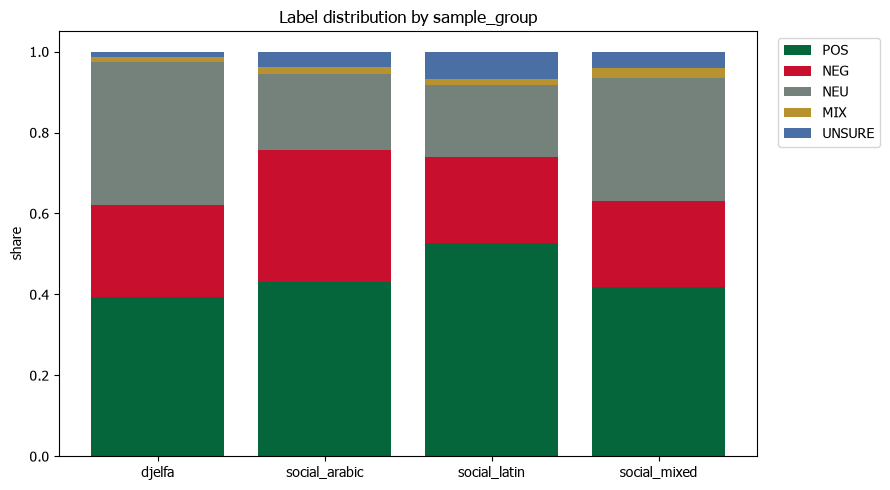

In [12]:
final_group = {r["id"]: pool_by_id[r["id"]]["sample_group"] for r in final if r["id"] in pool_by_id}
cross = pd.DataFrame(0, index=sorted(set(final_group.values())), columns=LABELS)
for r in final:
    g = final_group.get(r["id"])
    if g:
        cross.loc[g, r["label"]] += 1
cross_norm = cross.div(cross.sum(axis=1), axis=0)
display(cross)
display(cross_norm.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(cross_norm))
for lab in LABELS:
    ax.bar(cross_norm.index, cross_norm[lab], bottom=bottom, label=lab, color=LABEL_COLORS[lab])
    bottom += cross_norm[lab].values
ax.set_ylabel("share"); ax.set_title("Label distribution by sample_group")
ax.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

## 7. Disagreement set (for manual annotation)

29 overlap items where no label reached a 3/5 majority -- `data/disagreements.jsonl`, each with
a `manual_label: null` field to fill in.

In [13]:
for r in disagreements:
    text = r["text"].replace(chr(10), " / ")[:90]
    print(f"{r['votes']!s:32} {text}")

{'MIX': 1, 'POS': 2, 'NEG': 2}   رؤوف شباب على نسيم نسيم ماعندوش شارم 😂
{'NEG': 1, 'POS': 2, 'NEU': 2}   كي تكون تحكي نحسك واحد من تاع AD nat geo🤣🤣
{'POS': 1, 'UNSURE': 2, 'NEU': 2} يسمى الرايس هو لي يشري ...إييه فيها خير .
{'UNSURE': 2, 'POS': 2, 'NEU': 1} فرشات الاسنان غوز😂
{'NEU': 2, 'MIX': 1, 'NEG': 2}   السلام عليكم ❤ / ما نكذبش عليك انا مالنوع نخاف نطيب ماكلة وماتجيش بنينة وناس داري يحبو ماك
{'MIX': 2, 'POS': 2, 'NEU': 1}   كل التعليقات كارثة ولا واحد فيكم حط رايو فالمسلسل راكم قراف واحد. يطلب في لي جام واحد يطلب
{'NEU': 2, 'NEG': 1, 'UNSURE': 1, 'POS': 1} واش هو لبلتك
{'NEU': 2, 'POS': 2, 'NEG': 1}   +Syrine Zen بصحتك ختيتي من عندي هادي او يعطيه هه
{'UNSURE': 2, 'POS': 2, 'NEU': 1} هه والله إلا نيشان
{'NEU': 2, 'NEG': 2, 'MIX': 1}   bravo les homme خر #إنتخاب شاركت فيه كان في #الإبتدائي لإختيار رئيس القسم و كان الفائز إبن
{'NEG': 2, 'NEU': 1, 'POS': 2}   Salem aleykoum el maqadir taa mtaqba yarhame wallidik merci
{'UNSURE': 2, 'POS': 2, 'NEU': 1} خياتكم كامل عندهم ليموسطاش🤣🤣
{'U

## 9. Emoji use vs. sentiment

Reuses `Youtube_scrap/src/darija_corpus/clean_text.py`'s `_EMOJI_GRAPHEME_RE` directly rather
than re-deriving an emoji pattern (this repo's own convention -- see `CLAUDE.md`): it matches a
full emoji grapheme (base + optional VS16 + any ZWJ-joined continuations) as one unit, not
"emoji + one modifier", so a compound emoji like a ZWJ family sequence counts once.

**Caveat stated up front, not after the result**: the labeling prompt explicitly told every
agent that "repeated punctuation/emoji runs are expressive, not noise ... a real signal, not
something to discount." So a correlation here partly confirms the agents followed that
instruction, not an independent discovery -- treat it as a consistency check on the labeling,
not as external validation of it.

In [14]:
import sys
sys.path.insert(0, str(Path(r"C:\Users\ASUS\Desktop\summer 2026\Darija\Youtube_scrap\src")))
from darija_corpus.clean_text import _EMOJI_GRAPHEME_RE

def emojis_in(text: str) -> list[str]:
    return [m.group(0) for m in _EMOJI_GRAPHEME_RE.finditer(text)]

emoji_info = {r["id"]: emojis_in(r["text"]) for r in final}
has_emoji = {i: len(e) > 0 for i, e in emoji_info.items()}

overall_rate = sum(has_emoji.values()) / len(has_emoji)
print(f"Docs with at least one emoji: {sum(has_emoji.values()):,} / {len(has_emoji):,} ({overall_rate:.1%})")

Docs with at least one emoji: 2,223 / 9,971 (22.3%)


Emoji-presence rate by label (overall):
  POS     31.2%  (n=4,471)
  NEG     18.9%  (n=2,472)
  NEU     10.1%  (n=2,418)
  MIX     24.7%  (n=178)
  UNSURE  16.9%  (n=432)


,POS,NEG,NEU,MIX,UNSURE
djelfa,0.037,0.018,0.011,0.053,0.211
social_arabic,0.344,0.204,0.134,0.146,0.157
social_latin,0.381,0.224,0.112,0.233,0.188
social_mixed,0.328,0.229,0.129,0.382,0.140


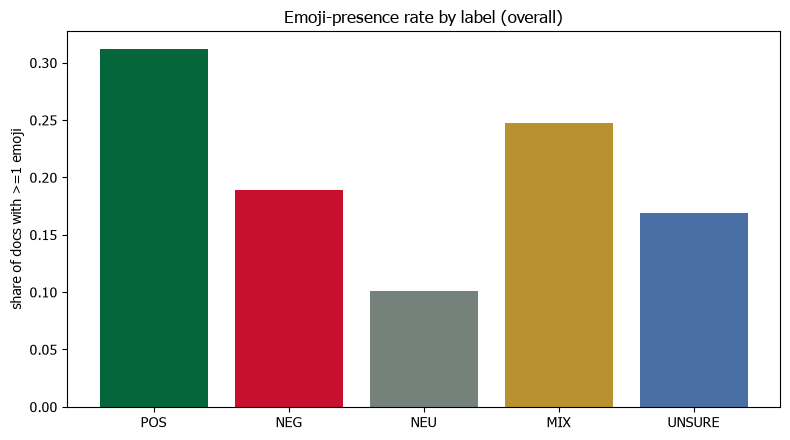

In [15]:
# Emoji-presence rate per label, overall and controlling for sample_group (the obvious confound --
# emoji use differs a lot by platform, and platform already correlates with label per section 6).
rate_by_label = {lab: np.mean([has_emoji[r["id"]] for r in final_by_label.get(lab, [])]) for lab in LABELS}
print("Emoji-presence rate by label (overall):")
for lab in LABELS:
    print(f"  {lab:7} {rate_by_label[lab]:.1%}  (n={len(final_by_label.get(lab, [])):,})")

rate_by_label_group = pd.DataFrame(index=sorted(set(final_group.values())), columns=LABELS, dtype=float)
for g in rate_by_label_group.index:
    for lab in LABELS:
        ids = [r["id"] for r in final if final_group.get(r["id"]) == g and r["label"] == lab]
        rate_by_label_group.loc[g, lab] = np.mean([has_emoji[i] for i in ids]) if ids else np.nan
display(rate_by_label_group.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(LABELS, [rate_by_label[l] for l in LABELS], color=[LABEL_COLORS[l] for l in LABELS])
ax.set_ylabel("share of docs with >=1 emoji"); ax.set_title("Emoji-presence rate by label (overall)")
plt.tight_layout(); plt.show()

In [16]:
# Chi-square test of independence: has_emoji x label
from scipy.stats import chi2_contingency

contingency = pd.DataFrame(0, index=LABELS, columns=["has_emoji", "no_emoji"])
for r in final:
    contingency.loc[r["label"], "has_emoji" if has_emoji[r["id"]] else "no_emoji"] += 1
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency.values)
print(f"chi2={chi2:.1f}, dof={dof}, p={p:.2e}")
print("(small p: has_emoji and label are not independent -- consistent with, not proof of, the causal",
      "story above; large n here makes even small real differences reach significance easily.)")

,has_emoji,no_emoji
POS,1394,3077
NEG,468,2004
NEU,244,2174
MIX,44,134
UNSURE,73,359


chi2=435.6, dof=4, p=5.75e-93
(small p: has_emoji and label are not independent -- consistent with, not proof of, the causal story above; large n here makes even small real differences reach significance easily.)


In [17]:
# Which specific emoji are disproportionately tied to which label -- ranked by lift
# (P(emoji | label) / P(emoji | overall)), not raw frequency, since raw counts are dominated by
# whichever emoji is just generally common (e.g. \U0001F602).
from collections import Counter as _Counter

overall_emoji_counts = _Counter(e for r in final for e in emoji_info[r["id"]])
overall_total = sum(overall_emoji_counts.values())

for lab in LABELS:
    rows = final_by_label.get(lab, [])
    lab_counts = _Counter(e for r in rows for e in emoji_info[r["id"]])
    lab_total = sum(lab_counts.values())
    if lab_total < 20:
        print(f"=== {lab}: too few emoji occurrences ({lab_total}) for a reliable ranking ===\n")
        continue
    scored = []
    for em, n in lab_counts.items():
        if n < 3:
            continue
        p_lab = n / lab_total
        p_overall = overall_emoji_counts[em] / overall_total
        scored.append((em, n, p_lab / p_overall))
    scored.sort(key=lambda x: -x[2])
    print(f"=== {lab} (top by lift, n>=3 within class, {lab_total} total emoji occurrences) ===")
    for em, n, lift in scored[:10]:
        print(f"  {em}  n={n:4}  lift={lift:5.2f}")
    print()

=== POS (top by lift, n>=3 within class, 2898 total emoji occurrences) ===
  💛  n=  11  lift= 1.71
  💟  n=   3  lift= 1.71
  💃  n=   3  lift= 1.71
  😙  n=  12  lift= 1.71
  😹  n=   3  lift= 1.71
  🌼  n=   3  lift= 1.71
  ⚘  n=   3  lift= 1.71
  ♦️  n=   3  lift= 1.71
  🥀  n=   3  lift= 1.71
  ♡  n=   3  lift= 1.71

=== NEG (top by lift, n>=3 within class, 1063 total emoji occurrences) ===
  🤦  n=   4  lift= 4.66
  😤  n=   3  lift= 4.66
  😣  n=   3  lift= 4.66
  🤬  n=   4  lift= 4.66
  🇷  n=   3  lift= 4.66
  🤧  n=   3  lift= 4.66
  🥴  n=   4  lift= 4.66
  🫲  n=   3  lift= 4.66
  😡  n=  10  lift= 4.66
  😖  n=   5  lift= 4.66

=== NEU (top by lift, n>=3 within class, 727 total emoji occurrences) ===
  ❁  n=   3  lift= 6.82
  🚨  n=   3  lift= 6.82
  🎵  n=   6  lift= 6.82
  ☁  n=  10  lift= 6.82
  🔵  n=   7  lift= 6.82
  ✔  n=   8  lift= 6.82
  🎁  n=   8  lift= 6.82
  📚  n= 158  lift= 6.69
  🎀  n=   9  lift= 6.14
  🍓  n=   5  lift= 5.68

=== MIX (top by lift, n>=3 within class, 109 total e

## 10. Top 20 unigrams and bigrams per class

Whitespace word split (`words_of`/`clean_for_classification` convention shared with
`Dialect_Identification/scripts/word_cluster/common.py`), `[MENTION]`/`[URL]` anonymization
placeholders stripped first since they're not content. Raw frequency, not filtered for
common function words -- the point here is what each class actually looks like, including the
generic Darija/MSA words that dominate every class (و, في, ربي, ...), not a distinctiveness ranking.

In [18]:
_MENTION_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_TOKEN_RE = re.compile(r"\[URL\]")

def words_of(text: str) -> list[str]:
    text = _MENTION_RE.sub("", text)
    text = _URL_TOKEN_RE.sub("", text)
    return text.split()

def bigrams_of(words: list[str]) -> list[tuple[str, str]]:
    return list(zip(words, words[1:]))

for lab in LABELS:
    rows = final_by_label.get(lab, [])
    uni = Counter(); bi = Counter()
    for r in rows:
        ws = words_of(r["text"])
        uni.update(ws)
        bi.update(bigrams_of(ws))
    print(f"=== {lab} (n={len(rows):,} docs) ===")
    print("Top 20 unigrams:", ", ".join(f"{w}({n})" for w, n in uni.most_common(20)))
    print("Top 20 bigrams: ", ", ".join(f"{a} {b}({n})" for (a, b), n in bi.most_common(20)))
    print()

=== POS (n=4,471 docs) ===
Top 20 unigrams: الله(1489), و(1370), في(1037), من(853), على(628), ربي(519), ،(380), كل(329), ما(311), ...(308), لا(297), .(286), يا(281), ان(266), et(251), شكرا(249), شاء(227), de(222), la(215), انا(214)
Top 20 bigrams:  شاء الله(211), بارك الله(144), السلام عليكم(132), يعطيك الصحة(128), الله فيك(124), ان شاء(122), ام وليد(93), ورحمة الله(69), ماشاء الله(59), oum walid(57), الله عليه(57), ربي يحفظك(54), الله يبارك(53), عليكم ورحمة(52), الحمد لله(51), صلى الله(51), انشاء الله(49), إن شاء(49), عليه وسلم(48), و الله(45)

=== NEG (n=2,472 docs) ===
Top 20 unigrams: و(1296), في(1232), من(1079), الله(772), على(533), لا(410), ما(350), .(297), ربي(281), ،(265), de(263), يا(260), ...(242), كل(237), لي(237), la(236), أن(222), انا(218), اللهم(205), هذا(204)


Top 20 bigrams: 

 السلام عليكم(58), اليه راجعون(57), الله و(42), لله و(42), شاء الله(42), ، و(40), انا لله(39), إنا لله(38), و لا(34), de la(34), الله عليه(34), الله ونعم(33), ونعم الوكيل(30), إليه راجعون(30), ) .(30), صلى الله(28), ان شاء(28), في الجزائر(27), لله وانا(27), لله وإنا(26)

=== NEU (n=2,418 docs) ===
Top 20 unigrams: من(2459), في(2433), الله(2002), ،(1383), و(1357), على(1269), أن(1033), :(933), لا(778), ما(735), .(700), عن(656), بن(649), قال(617), عليه(612), إلى(588), "(480), -(477), هذا(441), ولا(409)
Top 20 bigrams:  الله عليه(376), صلى الله(355), عليه وسلم(262), رسول الله(192), رضي الله(173), الله صلى(161), مكارم الأخلاق(159), 📚 مكارم(158), الأخلاق للخرائطي(158), رحمه الله(148), - قال(131), السلام عليكم(124), النبي صلى(108), الله تعالى(104), : ((100), ، و(100), الله عنه(99), : "(98), عبد الله(88), قال :(83)

=== MIX (n=178 docs) ===
Top 20 unigrams: و(176), في(83), ...(81), الله(80), من(72), ربي(52), على(48), لا(43), de(33), ما(33), les(32), et(29), انا(29), كل(27), .(26), la(24), والل

In [19]:
# Same thing as a browsable table instead of printed text, easier to scan/export
top_uni_rows, top_bi_rows = [], []
for lab in LABELS:
    rows = final_by_label.get(lab, [])
    uni = Counter(); bi = Counter()
    for r in rows:
        ws = words_of(r["text"])
        uni.update(ws)
        bi.update(bigrams_of(ws))
    for w, n in uni.most_common(20):
        top_uni_rows.append({"label": lab, "unigram": w, "count": n})
    for (a, b), n in bi.most_common(20):
        top_bi_rows.append({"label": lab, "bigram": f"{a} {b}", "count": n})

top_unigrams_df = pd.DataFrame(top_uni_rows)
top_bigrams_df = pd.DataFrame(top_bi_rows)
display(top_unigrams_df.pivot(columns="label", values="unigram").apply(lambda c: c.dropna().reset_index(drop=True)))

label,MIX,NEG,NEU,POS,UNSURE
0,و,و,من,الله,في
1,في,في,في,و,من
2,...,من,الله,في,على
3,الله,الله,،,من,قبيلة
4,من,على,و,على,و
5,ربي,لا,على,ربي,الله
6,على,ما,أن,،,نسب
7,لا,.,:,كل,pour
8,de,ربي,لا,ما,un
9,ما,،,ما,...,هتيم


## 8. Limitations / open questions

- **UNSURE's downstream treatment isn't decided** -- kept as a real 5th class here, but whether a
  sentiment classifier trained on this data should include or drop it is still open (see `../plan.md`).
- **No human-vs-LLM baseline yet** -- agreement here is cross-agent (5 LLM annotators), not validated
  against independent human labels. The 29 manual disagreement annotations are the closest thing to
  that so far, and only cover the hardest 2.9% of the overlap set by construction.
- **Fleiss' kappa here treats all 5 raters as interchangeable** -- it doesn't account for the fact
  they're 5 runs of the same underlying model/prompt rather than 5 independent human annotators, so
  a high kappa reflects prompt-following consistency more than it would for human raters.
- **This is run 1 (10K) of a project that works in runs** -- extending the pool via `build_dataset.py`
  and re-running the labeling agents on the new rows is the intended path for run 2, not redoing this.